In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.data import Data, Dataset, DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
import pandas as pd
import numpy as np
from tqdm import tqdm
import networkx as nx
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import re
from collections import Counter
from sklearn.model_selection import train_test_split
import spacy
import re
import emoji
import html


e:\Cyberbullying\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def clean_text(text):
    # 1. Decode HTML entities
    text = html.unescape(text)
    
    # 2. Lowercase the text
    text = text.lower()
    
    # 3. Replace URLs with a special token
    text = re.sub(r'http\S+|www.\S+', ' url ', text)
    
    # 4. Replace mentions and hashtags
    text = re.sub(r'@\w+', ' user ', text)
    text = re.sub(r'#\w+', ' hashtag ', text)
    
    # 5. Convert emojis to text (e.g., 😊 -> :smiling_face_with_smiling_eyes:)
    text = emoji.replace_emoji(text, replace='')
    
    # 6. Remove digits and punctuation (keep only words and spaces)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

def remove_repeated_words(text):
    # Replace 2 or more repeated words (consecutive) with a single word
    # e.g. "help help help" -> "help"
    return re.sub(r'\b(\w+)( \1\b)+', r'\1', text)

def remove_repeated_sentences(text):
    doc = nlp(text)
    seen = set()
    unique_sents = []
    for sent in doc.sents:
        sent_text = sent.text.strip()
        if sent_text not in seen:
            unique_sents.append(sent_text)
            seen.add(sent_text)
    return " ".join(unique_sents)

def clean_repeated(text):
    text = remove_repeated_words(text)
    text = remove_repeated_sentences(text)
    return text
def full_preprocess(text):
    text = clean_text(text)
    text = clean_repeated(text)
    return text

In [ ]:
def load_vidgen_dataset(path=r"E:\Cyberbullying\dataset\raw\Dynamically Generated Hate Dataset v0.2.2.csv"):
    """Loads the Vidgen dataset and maps labels."""
    vidgen_df = pd.read_csv(path)
    # Ensure the column name is correct, based on your notebook it was missing but used later.
    # Assuming 'label' is the column that needs mapping.
    vidgen_df = vidgen_df[['text', 'label']] # Adjusted based on your usage
    label_map = {'nothate': 0, 'hate': 1}
    vidgen_df['label'] = vidgen_df['label'].map(label_map)
    print(f"Loaded Vidgen dataset from {path}")
    print("Vidgen Label distribution:\n", vidgen_df['label'].value_counts()) #
    return vidgen_df

# === 1. Load Dataset ===
df = load_vidgen_dataset()

Loaded Vidgen dataset from E:\Cyberbullying\dataset\raw\Dynamically Generated Hate Dataset v0.2.2.csv
Vidgen Label distribution:
 label
1    22262
0    18993
Name: count, dtype: int64


KeyboardInterrupt: 

In [11]:
from sklearn.utils import resample

def balance_dataset(toxic_df):
    df_majority = toxic_df[toxic_df['label'] == 1]
    df_minority = toxic_df[toxic_df['label'] == 0]

    # Downsample majority class
    df_majority_downsampled = resample(df_majority,
                                    replace=False,     # without replacement
                                    n_samples=len(df_minority),  # match minority count
                                    random_state=42)

    # Combine balanced data
    df_balanced = pd.concat([df_majority_downsampled, df_minority])

    # Shuffle
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

    print(df_balanced['label'].value_counts())
    return df_balanced

df= balance_dataset(df)
    
    

label
0    18993
1    18993
Name: count, dtype: int64


In [12]:
# Apply your preprocessing
df["text"] = df["text"].apply(full_preprocess)

In [13]:
import numpy as np

# Load GloVe embeddings (once at the start)
def load_glove_embeddings(path=r"E:\Cyberbullying\glove\glove.6B.100d.txt"):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            embeddings[word] = vector
    return embeddings

glove = load_glove_embeddings()
embedding_dim = 100


In [14]:
import torch
from torch_geometric.data import Data

def text_to_graph(text, label, window_size=4):
    tokens = text.split()
    if len(tokens) == 0:
        # Avoid graph with no nodes: add dummy token
        tokens = ["<pad>"]

    num_tokens = len(tokens)

    x = []
    for token in tokens:
        if token in glove:
            x.append(glove[token])
        else:
            x.append(np.random.uniform(-0.1, 0.1, embedding_dim))
    x = torch.tensor(x, dtype=torch.float)

    edge_index = []
    for i in range(num_tokens):
        for j in range(i+1, min(i + window_size + 1, num_tokens)):
            edge_index.append([i, j])
            edge_index.append([j, i])
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    y = torch.tensor(label, dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)


In [15]:

from torch_geometric.data import Data, Dataset

class TextGraphDataset(Dataset):
    def __init__(self, df):
        super().__init__()
        self.graphs = [text_to_graph(text, label) for text, label in zip(df["text"], df["label"])]

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


In [16]:
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool

from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels=100, out_channels=hidden_channels, heads=2)
        self.conv2 = GATConv(hidden_channels * 2, out_channels=hidden_channels, heads=1)
        self.lin = nn.Linear(hidden_channels, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x)


In [ ]:

# === 3. Prepare DataLoaders ===
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
train_dataset = TextGraphDataset(train_df)
val_dataset = TextGraphDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32,drop_last=True)

# === 5. Training ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GAT(hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # Minimize validation loss
    factor=0.5,       # Reduce LR by half
    patience=2,       # Wait 2 epochs before reducing
    verbose=True,     # Log the LR reduction
    min_lr=1e-6       # Don't go below this
)
criterion = nn.CrossEntropyLoss()

best_val_loss = float('inf')
patience, counter = 10, 0

train_losses, val_losses = [], []

for epoch in range(1, 51):
    model.train()
    total_loss = 0
    correct = 0
    current_lr = optimizer.param_groups[0]['lr']
    for data in tqdm(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        # print(f"out shape: {out.shape}, y shape: {data.y.shape}")

        loss = criterion(out, data.y)
        loss.backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        pred = out.argmax(dim=1)
        correct += (pred == data.y).sum().item()

    train_acc = correct / len(train_loader.dataset)
    train_losses.append(total_loss / len(train_loader.dataset))

    model.eval()
    val_loss, val_correct = 0, 0
    all_preds, all_labels = [], []
    for data in val_loader:
        data = data.to(device)
        out = model(data)
        loss = criterion(out, data.y)
        val_loss += loss.item() * data.num_graphs
        pred = out.argmax(dim=1)
        val_correct += (pred == data.y).sum().item()
        all_preds.extend(pred.tolist())
        all_labels.extend(data.y.tolist())

    val_acc = val_correct / len(val_loader.dataset)
    val_loss_avg = val_loss / len(val_loader.dataset)
    val_losses.append(val_loss_avg)

    print(f"Epoch {epoch}, Train Acc: {train_acc:.4f}, Train loss:{train_losses[-1]:.4f} Val Acc: {val_acc:.4f},val loss: {val_losses[-1]:.4f},Epoch {epoch} - Learning Rate: {current_lr:.6f}")

    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        torch.save(model.state_dict(), "best_gnn_model.pt")
        counter = 0
        print("✅ New best model saved (val loss improved)")
    else:
        counter += 1
        print(f"⚠️ No improvement in val loss ({counter}/{patience})")
        if counter >= patience:
            print("⏹️ Early stopping triggered due to no val loss improvement")
            break

    scheduler.step(val_losses[-1])


e:\Cyberbullying\venv\Lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
e:\Cyberbullying\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
100%|██████████| 949/949 [00:30<00:00, 31.55it/s]


Epoch 1, Train Acc: 0.6352, Train loss:0.6222 Val Acc: 0.6537,val loss: 0.5995,Epoch 1 - Learning Rate: 0.010000
✅ New best model saved (val loss improved)


100%|██████████| 949/949 [00:30<00:00, 31.48it/s]


Epoch 2, Train Acc: 0.6523, Train loss:0.6024 Val Acc: 0.6454,val loss: 0.5973,Epoch 2 - Learning Rate: 0.010000
✅ New best model saved (val loss improved)


100%|██████████| 949/949 [00:30<00:00, 31.18it/s]


...

100%|██████████| 949/949 [00:33<00:00, 28.12it/s]


Epoch 16, Train Acc: 0.6771, Train loss:0.5740 Val Acc: 0.6753,val loss: 0.5842,Epoch 16 - Learning Rate: 0.010000
⚠️ No improvement in val loss (1/10)


100%|██████████| 949/949 [00:51<00:00, 18.59it/s]


Epoch 17, Train Acc: 0.6770, Train loss:0.5785 Val Acc: 0.6737,val loss: 0.5813,Epoch 17 - Learning Rate: 0.010000
⚠️ No improvement in val loss (2/10)


  2%|▏         | 23/949 [00:00<00:42, 21.56it/s]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.68      0.70      8783
           1       0.70      0.74      0.72      8785

    accuracy                           0.71     17568
   macro avg       0.71      0.71      0.71     17568
weighted avg       0.71      0.71      0.71     17568

Confusion Matrix:
 [[5934 2849]
 [2246 6539]]


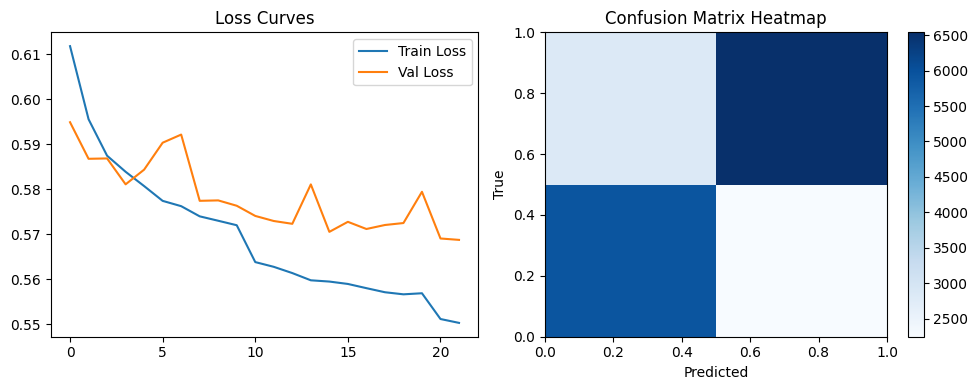

In [ ]:
# === 6. Evaluation ===
model.load_state_dict(torch.load("best_gnn_model.pt"))
model.eval()
all_preds, all_labels = [], []

for data in val_loader:
    data = data.to(device)
    out = model(data)
    pred = out.argmax(dim=1)
    all_preds.extend(pred.tolist())
    all_labels.extend(data.y.tolist())

print("Classification Report:\n", classification_report(all_labels, all_preds))
print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))

# === 7. Plotting ===
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curves")

plt.subplot(1, 2, 2)
plt.hist2d(all_labels, all_preds, bins=(2, 2), cmap=plt.cm.Blues)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()
